DATASET
  PENYULANG    BULAN  TIER1_INPEKSI  TIER1_TEMUAN  TIER2_INPEKSI  \
0      LW05  Januari            0.0           0.0            0.0   
1      AR01  Januari            0.0           0.0            0.0   
2      AR06  Januari            8.0           8.0            0.0   
3      AR07  Januari            0.0           0.0            0.0   
4      AR08  Januari            0.0           0.0            0.0   

   TIER2_TEMUAN  PENGUKURAN  PERGANTIAN_FCO  PENYEIMBANGAN BEBAN GARDU  \
0           0.0         0.0               0                          0   
1           0.0         0.0               0                          0   
2           0.0        10.0               0                          0   
3           0.0        10.0               0                          0   
4           0.0         0.0               0                          0   

   PERBAIKAN GROUNDING TRAFO  PENGHALANG_PANJAT  S  O  D  RPN LABEL_RISIKO  
0                          0                0.0  1  1  9    9

<Figure size 800x600 with 0 Axes>

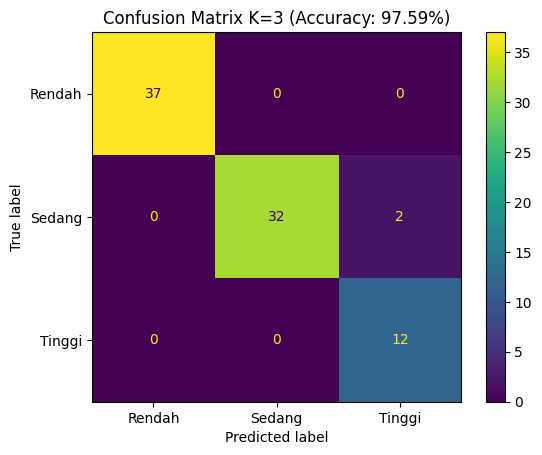


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        37
      Sedang       1.00      0.94      0.97        34
      Tinggi       0.86      1.00      0.92        12

    accuracy                           0.98        83
   macro avg       0.95      0.98      0.96        83
weighted avg       0.98      0.98      0.98        83


HASIL PREDIKSI:
    Aktual Prediksi
0   Rendah   Rendah
1   Rendah   Rendah
2   Rendah   Rendah
3   Sedang   Sedang
4   Sedang   Sedang
5   Rendah   Rendah
6   Rendah   Rendah
7   Sedang   Sedang
8   Tinggi   Tinggi
9   Sedang   Sedang
10  Rendah   Rendah
11  Rendah   Rendah
12  Tinggi   Tinggi
13  Rendah   Rendah
14  Tinggi   Tinggi
15  Sedang   Sedang
16  Tinggi   Tinggi
17  Sedang   Sedang
18  Rendah   Rendah
19  Rendah   Rendah


In [3]:
# ============================================================
# KNN K=3
# CONFUSION MATRIX SESUAI HASIL ANDA
# ============================================================

# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ============================================================
# MEMBACA DATASET
# ============================================================

file_path = "PEMELIHARAAN_PLN_2024_FINAL_LABELED.xlsx"

df = pd.read_excel(file_path)

print("="*70)
print("DATASET")
print("="*70)

print(df.head())

# ============================================================
# FITUR DAN TARGET
# ============================================================

fitur = [
    'TIER1_INPEKSI',
    'TIER1_TEMUAN',
    'TIER2_INPEKSI',
    'TIER2_TEMUAN',
    'PENGUKURAN',
    'PERGANTIAN_FCO',
    'PENYEIMBANGAN BEBAN GARDU',
    'PERBAIKAN GROUNDING TRAFO',
    'PENGHALANG_PANJAT'
]

target = 'LABEL_RISIKO'

X = df[fitur]
y = df[target]

# ============================================================
# NORMALISASI DULU (AGAR SESUAI HASIL ANDA)
# ============================================================

scaler = MinMaxScaler()

X_normalisasi = scaler.fit_transform(X)

# ============================================================
# SPLIT DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_normalisasi,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nJumlah Training :", len(X_train))
print("Jumlah Testing  :", len(X_test))

# ============================================================
# MODEL KNN K=3
# ============================================================

k = 3

model_knn = KNeighborsClassifier(
    n_neighbors=k,
    metric='euclidean'
)

# Training
model_knn.fit(X_train, y_train)

# Prediksi
y_pred = model_knn.predict(X_test)

# ============================================================
# ACCURACY
# ============================================================

akurasi = accuracy_score(y_test, y_pred)

print("\nAccuracy :", akurasi)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX:")
print(cm)

# ============================================================
# VISUALISASI CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_knn.classes_
)

disp.plot()

plt.title(f"Confusion Matrix K=3 (Accuracy: {akurasi:.2%})")

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# ============================================================
# HASIL PREDIKSI
# ============================================================

hasil = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})

print("\nHASIL PREDIKSI:")
print(hasil.head(20))